In [ ]:
# initialization
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy import constants
hbar = constants.physical_constants["reduced Planck constant in eV s"][0]
uB = constants.physical_constants["Bohr magneton in eV/T"][0] * 1e-3
g = constants.physical_constants["electron g factor"][0] * -1

# operators
U = Qobj([[0, 1/np.sqrt(2), -1/np.sqrt(2), 0],
           [0, 1/np.sqrt(2),  1/np.sqrt(2), 0],
           [1, 0, 0, 0],
           [0, 0, 0, 1]])
U.dims = [[2, 2], [2,2]] # qutip is pedantic

# this should be a class :p
def make_solver(j_numerator, k_s, k_d):
    # n, where n/2 is the nuclear spin
    j = j_numerator/2
    j_dim = j_numerator + 1

    # spin operator definitions
    sztot1 = tensor(U * tensor((1/2)*sigmaz(), qeye(2)) * U.dag(), qeye(j_dim))
    sztot2 = tensor(U * tensor(qeye(2), (1/2)*sigmaz()) * U.dag(), qeye(j_dim))
    sxtot1 = tensor(U * tensor((1/2)*sigmax(), qeye(2)) * U.dag(), qeye(j_dim))
    sxtot2 = tensor(U * tensor(qeye(2), (1/2)*sigmax()) * U.dag(), qeye(j_dim))
    sytot1 = tensor(U * tensor((1/2)*sigmay(), qeye(2)) * U.dag(), qeye(j_dim))
    sytot2 = tensor(U * tensor(qeye(2), (1/2)*sigmay()) * U.dag(), qeye(j_dim))

    iz = tensor(tensor(qeye(2), qeye(2)), spin_Jz(j))
    ix = tensor(tensor(qeye(2), qeye(2)), spin_Jx(j))
    iy = tensor(tensor(qeye(2), qeye(2)), spin_Jy(j))

    # defining projection operators
    singket = basis(4, 0) # 'singlet' and 'ket' ,,, get it?
    lower_proj_singlet = singket * singket.dag()
    lower_proj_singlet.dims = [[2,2], [2,2]] # qutip is pedantic
    lower_proj_triplet = (tensor(qeye(2), qeye(2)) - lower_proj_singlet) # triplets are everything that are not singlets

    # raised projection operators
    proj_singlet = tensor(lower_proj_singlet, qeye(j_dim))
    proj_triplet = tensor(lower_proj_triplet, qeye(j_dim))
    display

    # defining projection anticommutators
    def superanticommutator(proj_op, k):
        return k * (spre(proj_op) + spost(proj_op))
    singletanticom = superanticommutator(proj_singlet, k_s + k_d)
    tripletanticom = superanticommutator(proj_triplet, k_d)

    dim = 4 * j_dim

    # defining hamiltonians
    H_0 = g * uB * (sztot1 + sztot2)
    H_1 = g * uB * (ix * sxtot1 + iy * sytot1 + iz * sztot1)

    def solver(Bz):
        L = liouvillian(Bz * H_0 + H_1)/hbar + 1/2 * singletanticom + 1/2 * tripletanticom
        L_matrix = L.full()
        source = (1/dim) * np.eye(dim).flatten()
        L_matrix[-1, :] = [1 if i % (dim + 1) == 0 else 0 for i in range(dim**2)]
        source[-1] = 1.0
        # CUDA CALL
        rhoss = np.linalg.solve(L_matrix, source).reshape(dim, dim)
        return np.trace(proj_singlet.full() * rhoss)
    # initialization of solver function complete
    return solver
def do_solve(lower_bound, upper_bound, step, solver):
    Bzs = []
    tracesinglets = []
    a = 0
    b = np.abs(lower_bound) + np.abs(upper_bound) - step
    for Bz in np.arange(lower_bound, upper_bound, step):
        Bzs.append(Bz)
        tracesinglets.append(solver(Bz))
        print(f'Progress: {a/b*100:.2f}%', end='\r', flush=True)
        a += step
    plt.plot(Bzs, tracesinglets)
    return Bzs, tracesinglets

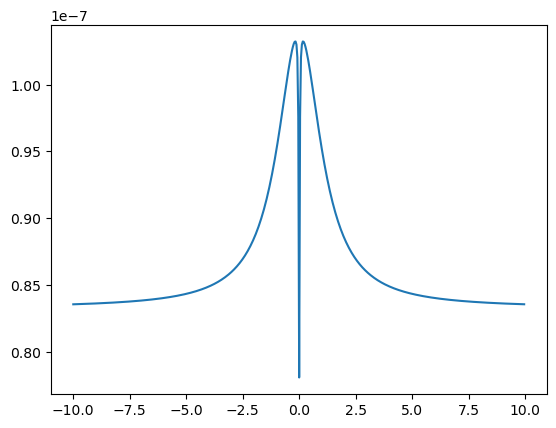

In [14]:
k_s = 4e6
k_d = 1e6
j = 1
low = -10
high = 10
step = .04
solver = make_solver(j, k_s, k_d)
spin1_2 = do_solve(low, high, step, solver)

/home/ryan/.conda/envs/harmon/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ryan/.conda/envs/harmon/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


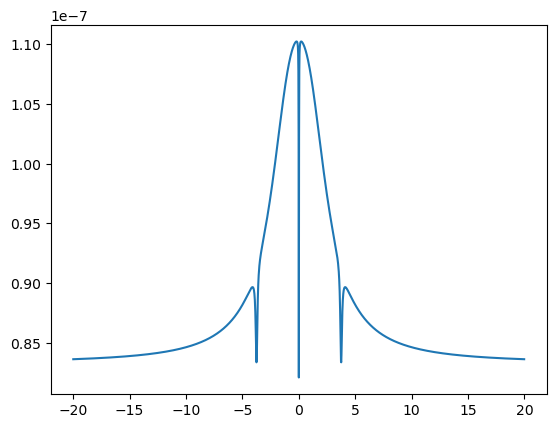

In [2]:
k_s = 4e6
k_d = 1e6
j = 3
low = -20
high = 20
step = .02
solver = make_solver(j, k_s, k_d)
spin3_2 = do_solve(low, high, step, solver)

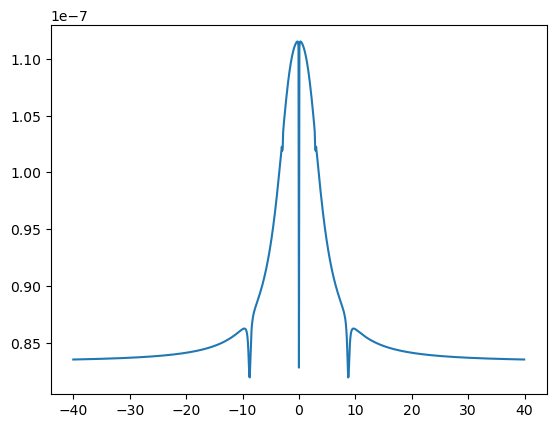

In [16]:
k_s = 4e6
k_d = 1e6
j = 5
low = -40
high = 40
step = .08
solver = make_solver(j, k_s, k_d)
spin5_2 = do_solve(low, high, step, solver)

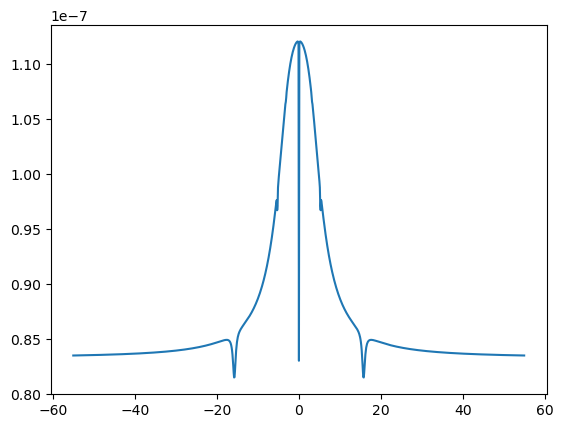

In [ ]:
k_s = 4e6
k_d = 1e6
j = 7
low = -55
high = 55
step = .1
# CUDA SWITCH POINT
# yeah i thinnk this one takes like 15 minutes on this computer :p
solver = make_solver(j, k_s, k_d)
spin7_2 = do_solve(low, high, step, solver)